# Which target should we train on? (`mean_pv` vs `auc` vs `auc_z`)

All three CTRPv2 scores trained head-to-head with the identical model: the legacy **`mean_pv`**
(dose-averaged percent viability — what Steps 04–05 used), the curve-fit **`auc`**, and the per-drug
z-scored **`auc_z`** (current default). The `auc_z` default was argued from first principles —
*"with 545 heads whose `auc` spread ranges 0.034–0.302, the wide-spread drugs supply ~80× more squared
error than the narrow ones and monopolize the shared trunk"* — but never **measured**. This notebook
measures it.

### Three methodological points, stated up front

**1. Why out-of-fold, not the fixed val split?** The fixed `split_ctrp` val fold holds only **27 cell
lines**, and a correlation over 27 points has a standard error of roughly **±0.2** — enough to
manufacture a spurious ±0.4 "result" (and it did: `2_training` reported −0.47 for `ml162`). So every model here
is evaluated **out-of-fold**: 5-fold GroupKFold over the 153 train+val lines; each fold trains a fresh
model and predicts **only the lines it never saw**; the five held-out prediction sets are pooled. No line
is ever scored by a model that trained on it — identical honesty, ~5× the sample (**~150 lines per
drug**). The 27 test lines stay untouched throughout.

**2. Spearman *and* Pearson.** Both reported. Both are affine-invariant, so neither is fooled by the
prediction shrinkage (`pred_std ≈ ρ·σ`, see `ablations_and_rescue`). Spearman leads because the targets carry genuine
outliers (one `cay10618` line sits ~6 SD out, which Pearson would let dominate) and because the question
— *which lines are sensitive* — is a ranking question. In practice they agree closely.

**3. Error bars — three different variances, don't conflate them.**
- **across cell lines** → 95% CI from bootstrapping the ~150 held-out lines (whiskers below).
- **across drugs** → the 5 drugs span ρ ≈ 0.1–0.65; shown as dots on each bar.
- **across seeds** → the one that decides whether scGPT's small lead over PCA is real. Checked separately
  at the end (3 seeds), because it costs a full retrain each.

### Why the cross-target comparison is fair — and the subtlety with `mean_pv`

`auc_z` is a *per-drug affine map* of `auc` (`auc_z = (auc − center[d]) / scale[d]`), and both
correlations are invariant to such a map — so those two share an **identical true ranking of cell
lines**, and the only channel between them is the **multi-task coupling** (how K heads share one trunk
through one masked loss).

`mean_pv` is **not** an affine map of `auc`: within a drug it ranks cell lines only ρ ≈ 0.72 the same.
Scoring a `mean_pv` model against `mean_pv` truth would answer a *different question*. So every model is
scored on **one common yardstick — the curve-fit `auc` ranking**: *which training target yields a model
that best recovers the real pharmacological ordering of cell lines?* Each model against its **own** target
is reported alongside, for continuity with `2_training`.

**Prediction** (for the `auc`/`auc_z` pair): indistinguishable at **K=5** (those 5 drugs have spread
0.155–0.194 — nothing to equalize), `auc_z` ahead at **K=545** (9× spread — the coupling bites).
`mean_pv` carries no prediction; it is here to show what Steps 04–05 were actually training on.

In [1]:
import os
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'scripts').is_dir())
NB_DIR = ROOT / 'notebooks'    # outputs always live in notebooks/outputs
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import torch
from scipy.stats import pearsonr, spearmanr
from sklearn.model_selection import GroupKFold
from torch.utils.data import DataLoader

from scripts.model.OncoMLP import OncoMLP
from scripts.model.dataset import MultiDrugDataset
from scripts.preprocessing.layout import PipelinePaths
from scripts.training.train_multitask import DEFAULT_HIDDEN_DIMS
from scripts.training.training_utils import TrainConfig, train_model

OUT = NB_DIR / 'outputs'
REPS = ['X_pca', 'X_scGPT']
SCORES = ['mean_pv', 'auc', 'auc_z']

lrn = pd.read_csv(OUT / 'learnability' / 'ctrp_drug_learnability_auc.csv')
FIVE = lrn[lrn['selected']].sort_values('learnability', ascending=False)['drug'].tolist()
print('evaluation drugs:', FIVE)
print('their auc spread:', lrn.set_index('drug').loc[FIVE, 'auc_std'].round(3).to_dict())

spread = lrn['auc_std']
print(f'\nper-drug auc spread over all {len(lrn)} drugs: min {spread.min():.3f} | '
      f'median {spread.median():.3f} | max {spread.max():.3f} -> {spread.max() / spread.min():.0f}x span'
      '  <- the reason z-scoring exists')

evaluation drugs: ['1s,3r-rsl-3', 'kx2-391', 'cay10618', 'ml162', 'dasatinib']
their auc spread: {'1s,3r-rsl-3': 0.194, 'kx2-391': 0.179, 'cay10618': 0.177, 'ml162': 0.156, 'dasatinib': 0.155}

per-drug auc spread over all 545 drugs: min 0.034 | median 0.109 | max 0.302 -> 9x span  <- the reason z-scoring exists


## The three targets on disk

Each `--score` writes its own targets h5ad, so all three already exist — **no preprocessing rerun needed**:

```bash
uv run scripts/preprocessing/run_preprocessing.py --variant hvg5000 --all-drugs \
    --score auc --start-at targets --skip-scgpt      # ..._with_targets_auc.h5ad
# auc_z   -> ..._with_targets_auc_z.h5ad   (the default)
# mean_pv -> ..._with_targets.h5ad         (the legacy un-suffixed file, Steps 04-05)
```

In [2]:
# Common yardstick: the curve-fit auc ranking. auc/auc_z share it exactly; mean_pv does not.
truth = sc.read_h5ad(PipelinePaths.build(None, 'hvg5000', 'auc').targets_h5ad, backed='r')
TRUTH_Y = np.asarray(truth.obsm['Y_ctrp'], dtype=float)
TRUTH_M = np.asarray(truth.obsm['M_ctrp'], dtype=bool)
TRUTH_DRUGS = list(truth.uns['ctrp_drugs'])


def oof_run(score, drugs, rep, eval_drugs, seed=42):
    """Train K=len(drugs) heads on `score`; return per-drug out-of-fold results.

    Keeps the per-line predicted/true vectors so a CI can be bootstrapped without retraining.
    """
    paths = PipelinePaths.build(None, 'hvg5000', score)
    adata = sc.read_h5ad(paths.targets_h5ad)
    eligible = adata.obs['split_ctrp'].isin(['train', 'val']).to_numpy()   # test never touched
    groups = adata.obs['Cell_line'].astype(str).to_numpy()
    idx = np.flatnonzero(eligible)
    Y = np.asarray(adata.obsm['Y_ctrp'], dtype=float)     # this score's own target values
    M = np.asarray(adata.obsm['M_ctrp'], dtype=bool)
    ALL = list(adata.uns['ctrp_drugs'])

    cfg = TrainConfig(epochs=50, seed=seed, log_every=1000)
    pred = np.full((adata.n_obs, len(drugs)), np.nan)
    for fold, (tr, va) in enumerate(GroupKFold(n_splits=5).split(idx, groups=groups[idx]), 1):
        trc = np.zeros(adata.n_obs, bool); trc[idx[tr]] = True
        vac = np.zeros(adata.n_obs, bool); vac[idx[va]] = True
        tr_ds = MultiDrugDataset(adata=adata, use_rep=rep, cell_mask=trc, drugs=drugs)
        va_ds = MultiDrugDataset(adata=adata, use_rep=rep, cell_mask=vac, drugs=drugs)
        model = OncoMLP(input_dim=tr_ds.X.shape[1], hidden_dims=DEFAULT_HIDDEN_DIMS[rep],
                        dropout_rate=0.5, input_dropout=0.1, norm='layer',
                        output_dim=len(tr_ds.drug_names))
        best, _ = train_model(model, DataLoader(tr_ds, batch_size=128, shuffle=True),
                              DataLoader(va_ds, batch_size=256, shuffle=False),
                              config=cfg, tag=f'{score}_{rep}_K{len(drugs)}_s{seed}_f{fold}',
                              drug_names=tr_ds.drug_names)
        best = best.to('cpu').eval()                      # train_model leaves it on mps/cuda
        with torch.no_grad():
            X = torch.tensor(np.asarray(adata.obsm[rep], dtype=np.float32)[vac])
            pred[vac] = best(X).numpy()                   # held-out lines only

    out = []
    for drug in eval_drugs:
        j, k, kt = drugs.index(drug), ALL.index(drug), TRUTH_DRUGS.index(drug)
        p, t_own, t_auc = [], [], []
        for line in np.unique(groups[eligible]):
            ci = np.flatnonzero((groups == line) & eligible)
            obs = ci[M[ci, k] & TRUTH_M[ci, kt] & np.isfinite(pred[ci, j])]
            if obs.size:
                p.append(pred[obs, j].mean())             # cells -> one value per cell line
                t_own.append(Y[obs, k].mean())
                t_auc.append(TRUTH_Y[obs, kt].mean())
        p, t_own, t_auc = map(np.asarray, (p, t_own, t_auc))
        out.append({'score': score, 'heads': f'K={len(drugs)}', 'rep': rep, 'drug': drug, 'seed': seed,
                    'n_lines': p.size,
                    'spearman': spearmanr(p, t_auc).statistic,
                    'pearson': pearsonr(p, t_auc)[0],
                    'spearman_own': spearmanr(p, t_own).statistic,
                    '_p': p, '_t': t_auc})
    return out

## Train: 3 targets × 2 head-counts × 2 representations

In [3]:
rows = []
for score in SCORES:
    all_drugs = list(sc.read_h5ad(PipelinePaths.build(None, 'hvg5000', score).targets_h5ad,
                                  backed='r').uns['ctrp_drugs'])
    for drugs, kname in [(FIVE, 'K=5'), (all_drugs, 'K=545')]:
        for rep in REPS:
            res = oof_run(score, drugs, rep, FIVE)
            rows.extend(res)
            print(f'{score:8s} {kname:6s} {rep:8s} '
                  f'spearman={np.mean([r["spearman"] for r in res]):+.3f}  '
                  f'pearson={np.mean([r["pearson"] for r in res]):+.3f}  '
                  f'(vs own target: {np.mean([r["spearman_own"] for r in res]):+.3f})', flush=True)

df = pd.DataFrame(rows)
df.drop(columns=['_p', '_t']).to_csv(OUT / 'target' / 'target_comparison.csv', index=False)

print('\n=== mean over the 5 drugs, on the COMMON curve-fit auc ranking ===')
for metric in ['spearman', 'pearson']:
    print(f'\n{metric}:')
    print(df.groupby(['heads', 'rep', 'score'])[metric].mean().unstack('score')[SCORES].round(3).to_string())
print('\n=== each model against its OWN training target (continuity with 07) ===')
print(df.groupby(['heads', 'rep', 'score'])['spearman_own'].mean().unstack('score')[SCORES].round(3).to_string())

Loaded 33000 cells for the 'custom-mask' set. K=5 drugs | mean drugs/cell=4.9 | min drug coverage=31805 cells | max drug coverage=32724 cells.
Loaded 8247 cells for the 'custom-mask' set. K=5 drugs | mean drugs/cell=4.9 | min drug coverage=7854 cells | max drug coverage=8247 cells.
[mean_pv_X_pca_K5_s42_f1] Training on device: mps
[mean_pv_X_pca_K5_s42_f1] Multi-task mode detected (masked MSE).


[mean_pv_X_pca_K5_s42_f1] Epoch [01/50] | Train MSE: 0.0729 | Val MSE: 0.0182 | LR: 1.0e-03  <- best
  best : dasatinib:0.012(n=7918), ml162:0.013(n=8247), cay10618:0.015(n=7854), 1s,3r-rsl-3:0.017(n=8247), kx2-391:0.033(n=8183)
  worst: kx2-391:0.033(n=8183), 1s,3r-rsl-3:0.017(n=8247), cay10618:0.015(n=7854), ml162:0.013(n=8247), dasatinib:0.012(n=7918)


[mean_pv_X_pca_K5_s42_f1] Early stopping at epoch 11 (no val improvement for 10 epochs).
[mean_pv_X_pca_K5_s42_f1] Training complete. Best Val MSE: 0.0182 at epoch 1.
Loaded 32995 cells for the 'custom-mask' set. K=5 drugs | mean drugs/cell=4.9 | min drug coverage=32269 cells | max drug coverage=32616 cells.
Loaded 8252 cells for the 'custom-mask' set. K=5 drugs | mean drugs/cell=4.8 | min drug coverage=7464 cells | max drug coverage=8252 cells.
[mean_pv_X_pca_K5_s42_f2] Training on device: mps
[mean_pv_X_pca_K5_s42_f2] Multi-task mode detected (masked MSE).


[mean_pv_X_pca_K5_s42_f2] Epoch [01/50] | Train MSE: 0.0723 | Val MSE: 0.0239 | LR: 1.0e-03  <- best
  best : ml162:0.017(n=8252), cay10618:0.021(n=7701), 1s,3r-rsl-3:0.026(n=7464), kx2-391:0.027(n=8252), dasatinib:0.029(n=8252)
  worst: dasatinib:0.029(n=8252), kx2-391:0.027(n=8252), 1s,3r-rsl-3:0.026(n=7464), cay10618:0.021(n=7701), ml162:0.017(n=8252)


[mean_pv_X_pca_K5_s42_f2] Early stopping at epoch 11 (no val improvement for 10 epochs).
[mean_pv_X_pca_K5_s42_f2] Training complete. Best Val MSE: 0.0239 at epoch 1.
Loaded 32990 cells for the 'custom-mask' set. K=5 drugs | mean drugs/cell=4.9 | min drug coverage=31713 cells | max drug coverage=32990 cells.
Loaded 8257 cells for the 'custom-mask' set. K=5 drugs | mean drugs/cell=5.0 | min drug coverage=7878 cells | max drug coverage=8257 cells.
[mean_pv_X_pca_K5_s42_f3] Training on device: mps
[mean_pv_X_pca_K5_s42_f3] Multi-task mode detected (masked MSE).


...

[auc_z_X_scGPT_K545_s42_f5] Epoch [08/50] | Train MSE: 0.7046 | Val MSE: 0.9968 | LR: 1.0e-03  <- best
  best : sr8278:0.042(n=1242), brd-k33514849:0.101(n=1242), bafilomycin a1:0.106(n=1242), cyclophosphamide:0.164(n=3785), pyr-41:0.166(n=8252)
  worst: cbb-1007:4.008(n=4467), sz4ta2:3.727(n=4467), sch-529074:3.578(n=8252), bcl-lzh-4:3.353(n=4467), brd-k13999467:3.195(n=8252)


[auc_z_X_scGPT_K545_s42_f5] Epoch [13/50] | Train MSE: 0.6809 | Val MSE: 0.9924 | LR: 5.0e-04  <- best
  best : sr8278:0.032(n=1242), brd-k33514849:0.162(n=1242), bafilomycin a1:0.167(n=1242), cimetidine:0.168(n=1975), cyclophosphamide:0.177(n=3785)
  worst: cbb-1007:4.007(n=4467), sz4ta2:3.761(n=4467), sch-529074:3.599(n=8252), bcl-lzh-4:3.323(n=4467), brd-k13999467:3.213(n=8252)


[auc_z_X_scGPT_K545_s42_f5] Early stopping at epoch 23 (no val improvement for 10 epochs).
[auc_z_X_scGPT_K545_s42_f5] Training complete. Best Val MSE: 0.9924 at epoch 13.


auc_z    K=545  X_scGPT  spearman=+0.430  pearson=+0.425  (vs own target: +0.430)



=== mean over the 5 drugs, on the COMMON curve-fit auc ranking ===

spearman:
score          mean_pv    auc  auc_z
heads rep                           
K=5   X_pca      0.450  0.439  0.424
      X_scGPT    0.481  0.482  0.488
K=545 X_pca      0.027  0.016  0.378
      X_scGPT   -0.070 -0.087  0.430

pearson:
score          mean_pv    auc  auc_z
heads rep                           
K=5   X_pca      0.425  0.437  0.408
      X_scGPT    0.480  0.477  0.482
K=545 X_pca      0.037  0.007  0.368
      X_scGPT   -0.053 -0.088  0.425

=== each model against its OWN training target (continuity with 07) ===
score          mean_pv    auc  auc_z
heads rep                           
K=5   X_pca      0.451  0.439  0.424
      X_scGPT    0.476  0.482  0.488
K=545 X_pca      0.020  0.016  0.378
      X_scGPT   -0.074 -0.087  0.430


## Error bars: bootstrap over cell lines + the per-drug spread

The bar is the mean over the 5 drugs. The **whisker is a 95% bootstrap CI over the ~150 held-out cell
lines** (resample lines with replacement, recompute each drug's Spearman, average; 1,000 draws). The
**dots are the 5 individual drugs** — the variance a mean inevitably hides.

In [4]:
def bootstrap_ci(sub, n_boot=1000, seed=42):
    """95% CI of the 5-drug mean Spearman, resampling CELL LINES (the independent unit)."""
    rng = np.random.default_rng(seed)
    pairs = [(r['_p'], r['_t']) for _, r in sub.iterrows()]
    means = []
    for _ in range(n_boot):
        rhos = []
        for p, t in pairs:
            b = rng.integers(0, len(p), len(p))       # resample lines within each drug
            if np.unique(t[b]).size < 3:
                continue
            rhos.append(spearmanr(p[b], t[b]).statistic)
        if rhos:
            means.append(np.mean(rhos))
    return np.percentile(means, [2.5, 97.5])


bars = []
for (heads, rep, score), sub in df.groupby(['heads', 'rep', 'score']):
    lo, hi = bootstrap_ci(sub)
    bars.append({'heads': heads, 'rep': rep, 'score': score, 'mean': sub['spearman'].mean(),
                 'ci_lo': lo, 'ci_hi': hi,
                 'drug_min': sub['spearman'].min(), 'drug_max': sub['spearman'].max()})
bars = pd.DataFrame(bars)
bars.to_csv(OUT / 'target' / 'target_comparison_ci.csv', index=False)
print(bars.round(3).to_string(index=False))

heads     rep   score   mean  ci_lo  ci_hi  drug_min  drug_max
  K=5   X_pca     auc  0.439  0.375  0.491     0.111     0.597
  K=5   X_pca   auc_z  0.424  0.363  0.478     0.102     0.572
  K=5   X_pca mean_pv  0.450  0.386  0.504     0.116     0.600
  K=5 X_scGPT     auc  0.482  0.418  0.533     0.305     0.623
  K=5 X_scGPT   auc_z  0.488  0.428  0.536     0.283     0.655
  K=5 X_scGPT mean_pv  0.481  0.417  0.532     0.299     0.615
K=545   X_pca     auc  0.016 -0.057  0.091    -0.041     0.119
K=545   X_pca   auc_z  0.378  0.312  0.437     0.153     0.521
K=545   X_pca mean_pv  0.027 -0.044  0.097    -0.025     0.148
K=545 X_scGPT     auc -0.087 -0.154 -0.017    -0.136     0.000
K=545 X_scGPT   auc_z  0.430  0.368  0.483     0.261     0.522
K=545 X_scGPT mean_pv -0.070 -0.143  0.001    -0.111    -0.005


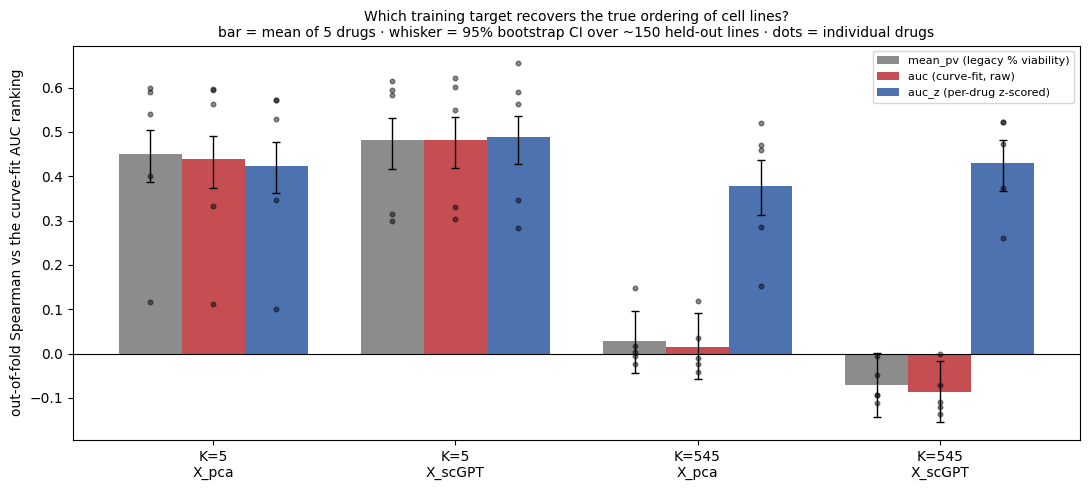

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
cols = {'mean_pv': '#8C8C8C', 'auc': '#C44E52', 'auc_z': '#4C72B0'}
names = {'mean_pv': 'mean_pv (legacy % viability)', 'auc': 'auc (curve-fit, raw)',
         'auc_z': 'auc_z (per-drug z-scored)'}
groups_ = [('K=5', 'X_pca'), ('K=5', 'X_scGPT'), ('K=545', 'X_pca'), ('K=545', 'X_scGPT')]
x = np.arange(len(groups_)); w = 0.26

for i, sc_ in enumerate(SCORES):
    m, lo, hi = [], [], []
    for g in groups_:
        b = bars[(bars.heads == g[0]) & (bars.rep == g[1]) & (bars.score == sc_)].iloc[0]
        m.append(b['mean']); lo.append(b['mean'] - b['ci_lo']); hi.append(b['ci_hi'] - b['mean'])
    pos = x + (i - 1) * w
    ax.bar(pos, m, w, label=names[sc_], color=cols[sc_], zorder=2)
    ax.errorbar(pos, m, yerr=[lo, hi], fmt='none', ecolor='k', capsize=3, lw=1, zorder=4)
    for xi, g in zip(pos, groups_):
        d = df[(df.heads == g[0]) & (df.rep == g[1]) & (df.score == sc_)]['spearman']
        ax.scatter(np.full(len(d), xi), d, s=11, color='k', alpha=0.45, zorder=5)

ax.axhline(0, color='k', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}\n{r}' for h, r in groups_])
ax.set_ylabel('out-of-fold Spearman vs the curve-fit AUC ranking')
ax.set_title('Which training target recovers the true ordering of cell lines?\n'
             'bar = mean of 5 drugs · whisker = 95% bootstrap CI over ~150 held-out lines · dots = individual drugs',
             fontsize=10)
ax.legend(fontsize=8, loc='upper right')
fig.tight_layout()
fig.savefig(OUT / 'target' / 'target_comparison.png', dpi=200)
plt.show()

## Seed stability — is scGPT's lead over PCA real?

The bootstrap CI above covers **cell-line sampling** noise, not **training** noise. The `auc_z`-vs-`auc`
gap at K=545 is enormous and safe from either. But **scGPT beats PCA by only ~0.06**, and `2_training` §2 already
showed fold-to-fold variance large enough to swallow a gap that size. So: re-run the K=545 `auc_z`
configuration at three seeds. **If the ordering flips, the lead is not a result and must not be claimed.**

In [6]:
seed_rows = []
all_drugs = list(sc.read_h5ad(PipelinePaths.build(None, 'hvg5000', 'auc_z').targets_h5ad,
                              backed='r').uns['ctrp_drugs'])
for seed in [42, 1, 7]:
    for rep in REPS:
        res = oof_run('auc_z', all_drugs, rep, FIVE, seed=seed)
        m = np.mean([r['spearman'] for r in res])
        seed_rows.append({'seed': seed, 'rep': rep, 'spearman': m})
        print(f'seed {seed:>2} | {rep:8s} spearman={m:+.3f}', flush=True)

sd = pd.DataFrame(seed_rows)
sd.to_csv(OUT / 'target' / 'seed_stability.csv', index=False)
piv = sd.pivot(index='seed', columns='rep', values='spearman')
piv['scGPT - PCA'] = piv['X_scGPT'] - piv['X_pca']
print()
print(piv.round(3).to_string())
gap = piv['scGPT - PCA']
print(f'\nscGPT - PCA: mean {gap.mean():+.3f}, sd {gap.std():.3f}, '
      f'sign consistent across seeds: {bool((gap > 0).all() or (gap < 0).all())}')

Loaded 33000 cells for the 'custom-mask' set. K=545 drugs | mean drugs/cell=457.0 | min drug coverage=3023 cells | max drug coverage=33000 cells.
Loaded 8247 cells for the 'custom-mask' set. K=545 drugs | mean drugs/cell=454.2 | min drug coverage=233 cells | max drug coverage=8247 cells.
[auc_z_X_pca_K545_s42_f1] Training on device: mps
[auc_z_X_pca_K545_s42_f1] Multi-task mode detected (masked MSE).


[auc_z_X_pca_K545_s42_f1] Epoch [01/50] | Train MSE: 0.8850 | Val MSE: 0.7878 | LR: 1.0e-03  <- best
  best : brd-k33514849:0.003(n=233), sr8278:0.013(n=233), bafilomycin a1:0.043(n=233), brd-k01737880:0.081(n=233), brd-k90370028:0.101(n=5345)
  worst: navitoclax:birinapant (1:1 mol/mol):4.768(n=8107), serdemetan:3.688(n=8247), ml006:3.233(n=7918), fsc231:3.030(n=2404), etoposide:2.682(n=7918)


[auc_z_X_pca_K545_s42_f1] Early stopping at epoch 11 (no val improvement for 10 epochs).
[auc_z_X_pca_K545_s42_f1] Training complete. Best Val MSE: 0.7878 at epoch 1.
Loaded 32995 cells for the 'custom-mask' set. K=545 drugs | mean drugs/cell=456.2 | min drug coverage=1896 cells | max drug coverage=32995 cells.
Loaded 8252 cells for the 'custom-mask' set. K=545 drugs | mean drugs/cell=457.6 | min drug coverage=1248 cells | max drug coverage=8252 cells.
[auc_z_X_pca_K545_s42_f2] Training on device: mps
[auc_z_X_pca_K545_s42_f2] Multi-task mode detected (masked MSE).


[auc_z_X_pca_K545_s42_f2] Epoch [01/50] | Train MSE: 0.8101 | Val MSE: 1.1587 | LR: 1.0e-03  <- best
  best : brd-k33514849:0.033(n=1360), fgin-1-27:0.059(n=1410), bafilomycin a1:0.070(n=1360), cimetidine:0.072(n=1410), brd-k13185470:0.090(n=1410)
  worst: cil41:9.220(n=3815), brd-k27188169:8.239(n=3578), marinopyrrole a:4.944(n=6706), mi-1:4.792(n=6892), pandacostat:4.778(n=8252)


[auc_z_X_pca_K545_s42_f2] Early stopping at epoch 11 (no val improvement for 10 epochs).
[auc_z_X_pca_K545_s42_f2] Training complete. Best Val MSE: 1.1587 at epoch 1.
Loaded 32990 cells for the 'custom-mask' set. K=545 drugs | mean drugs/cell=455.9 | min drug coverage=2916 cells | max drug coverage=32990 cells.
Loaded 8257 cells for the 'custom-mask' set. K=545 drugs | mean drugs/cell=458.5 | min drug coverage=340 cells | max drug coverage=8257 cells.
[auc_z_X_pca_K545_s42_f3] Training on device: mps
[auc_z_X_pca_K545_s42_f3] Multi-task mode detected (masked MSE).


...

[auc_z_X_scGPT_K545_s7_f5] Epoch [05/50] | Train MSE: 0.7188 | Val MSE: 0.9990 | LR: 1.0e-03  <- best
  best : sr8278:0.029(n=1242), cyclophosphamide:0.152(n=3785), pyr-41:0.176(n=8252), cimetidine:0.180(n=1975), brd-k33514849:0.190(n=1242)
  worst: cbb-1007:4.096(n=4467), sz4ta2:3.917(n=4467), sch-529074:3.590(n=8252), bcl-lzh-4:3.308(n=4467), brd-k13999467:3.187(n=8252)


[auc_z_X_scGPT_K545_s7_f5] Epoch [09/50] | Train MSE: 0.7031 | Val MSE: 0.9973 | LR: 1.0e-03  <- best
  best : sr8278:0.039(n=1242), brd-k33514849:0.133(n=1242), cyclophosphamide:0.134(n=3785), bafilomycin a1:0.141(n=1242), cimetidine:0.175(n=1975)
  worst: cbb-1007:4.037(n=4467), sz4ta2:3.823(n=4467), sch-529074:3.616(n=8252), bcl-lzh-4:3.285(n=4467), brd-k13999467:3.166(n=8252)


[auc_z_X_scGPT_K545_s7_f5] Early stopping at epoch 19 (no val improvement for 10 epochs).
[auc_z_X_scGPT_K545_s7_f5] Training complete. Best Val MSE: 0.9973 at epoch 9.


seed  7 | X_scGPT  spearman=+0.472



rep   X_pca  X_scGPT  scGPT - PCA
seed                             
1     0.367    0.434        0.066
7     0.355    0.472        0.117
42    0.388    0.430        0.043

scGPT - PCA: mean +0.075, sd 0.038, sign consistent across seeds: True


## Read-out

*(Filled in from the executed cells above — see the committed outputs and `docs/steps/03`.)*

The three questions this notebook answers:

1. **Is per-drug z-scoring load-bearing?** Compare red (`auc`) vs blue (`auc_z`) at **K=545**. A collapse
   of raw `auc` to ≈0 while `auc_z` holds confirms the multi-task-coupling argument: with spreads spanning
   9×, the wide-spread heads monopolize the shared trunk **by unit size, not learnability**. At **K=5** the
   two should be indistinguishable — and if they are, **`--score auc` is equally good on a filtered
   subset**, with the advantage of native, interpretable AUC units.
2. **What were Steps 04–05 actually training on?** The grey (`mean_pv`) bar. It carries the same
   heterogeneous-variance pathology, so at K=545 it should fail the way raw `auc` does — which is what
   makes `2_training` §3's null result an **artifact of the loss**, not evidence about scGPT vs PCA.
3. **Is scGPT's lead over PCA real?** Only the seed table answers that. A sign flip across seeds means the
   +0.06 is noise.